**Imports**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Carga de la data desde github**

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/Nicossm/Housing_Prices_ML_P1/Javier/data/raw/Ames_Iowa_Housing_Dataset.csv')

**EDA**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [5]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [6]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## Diccionario de Variables — Ames Housing Dataset

| Variable | Definición | Tipo |
|---|---|---|
| `Order` | Número de orden/índice de la observación | Identificador |
| `PID` | Parcel ID — identificador único de la propiedad en el catastro | Identificador |
| `MS SubClass` | Código del tipo de vivienda (clase de construcción: 1 piso, 2 pisos, split-level, etc.) | Cualitativa nominal |
| `MS Zoning` | Clasificación de zonificación general (residencial, comercial, etc.) | Cualitativa nominal |
| `Lot Frontage` | Metros lineales de calle conectados a la propiedad | Cuantitativa continua |
| `Lot Area` | Superficie del terreno (pies²) | Cuantitativa continua |
| `Street` | Tipo de acceso vial (grava o pavimentado) | Cualitativa nominal |
| `Alley` | Tipo de acceso por callejón (grava, pavimentado, o sin acceso) | Cualitativa nominal |
| `Lot Shape` | Forma general del terreno (regular/irregular) | Cualitativa ordinal |
| `Land Contour` | Planitud del terreno (plano, con pendiente, hundido, etc.) | Cualitativa nominal |
| `Utilities` | Tipo de servicios públicos disponibles (electricidad, agua, gas, alcantarillado) | Cualitativa ordinal |
| `Lot Config` | Configuración del lote (esquina, interior, cul-de-sac, etc.) | Cualitativa nominal |
| `Land Slope` | Pendiente del terreno (suave, moderada, pronunciada) | Cualitativa ordinal |
| `Neighborhood` | Ubicación física dentro de los límites de la ciudad de Ames | Cualitativa nominal |
| `Condition 1` | Proximidad a condiciones especiales (vía férrea, avenida principal, parque, etc.) | Cualitativa nominal |
| `Condition 2` | Segunda condición especial (si aplica más de una) | Cualitativa nominal |
| `Bldg Type` | Tipo de vivienda (unifamiliar, dúplex, townhouse, etc.) | Cualitativa nominal |
| `House Style` | Estilo de la vivienda (un piso, dos pisos, split-level, etc.) | Cualitativa nominal |
| `Overall Qual` | Calidad general de materiales y acabados (escala 1-10) | Cualitativa ordinal |
| `Overall Cond` | Condición general de la vivienda (escala 1-10) | Cualitativa ordinal |
| `Year Built` | Año de construcción original | Cuantitativa discreta |
| `Year Remod/Add` | Año de la última remodelación o ampliación | Cuantitativa discreta |
| `Roof Style` | Tipo de techo (a dos aguas, plano, mansarda, etc.) | Cualitativa nominal |
| `Roof Matl` | Material del techo | Cualitativa nominal |
| `Exterior 1st` | Material de revestimiento exterior (principal) | Cualitativa nominal |
| `Exterior 2nd` | Material de revestimiento exterior (secundario, si hay más de uno) | Cualitativa nominal |
| `Mas Vnr Type` | Tipo de revestimiento de mampostería en fachada (ladrillo, piedra, ninguno) | Cualitativa nominal |
| `Mas Vnr Area` | Área del revestimiento de mampostería (pies²) | Cuantitativa continua |
| `Exter Qual` | Calidad del material exterior | Cualitativa ordinal |
| `Exter Cond` | Condición actual del material exterior | Cualitativa ordinal |
| `Foundation` | Tipo de cimentación (hormigón, bloque, piedra, etc.) | Cualitativa nominal |
| `Bsmt Qual` | Calidad del sótano (altura del sótano) | Cualitativa ordinal |
| `Bsmt Cond` | Condición general del sótano | Cualitativa ordinal |
| `Bsmt Exposure` | Exposición del sótano a nivel de jardín (walkout, ventanas, etc.) | Cualitativa ordinal |
| `BsmtFin Type 1` | Calidad del área terminada principal del sótano | Cualitativa ordinal |
| `BsmtFin SF 1` | Superficie terminada del sótano, tipo 1 (pies²) | Cuantitativa continua |
| `BsmtFin Type 2` | Calidad del área terminada secundaria del sótano | Cualitativa ordinal |
| `BsmtFin SF 2` | Superficie terminada del sótano, tipo 2 (pies²) | Cuantitativa continua |
| `Bsmt Unf SF` | Superficie de sótano sin terminar (pies²) | Cuantitativa continua |
| `Total Bsmt SF` | Superficie total del sótano (pies²) | Cuantitativa continua |
| `Heating` | Tipo de sistema de calefacción | Cualitativa nominal |
| `Heating QC` | Calidad y condición de la calefacción | Cualitativa ordinal |
| `Central Air` | Aire acondicionado central (Sí/No) | Cualitativa nominal |
| `Electrical` | Tipo de sistema eléctrico | Cualitativa nominal |
| `1st Flr SF` | Superficie del primer piso (pies²) | Cuantitativa continua |
| `2nd Flr SF` | Superficie del segundo piso (pies²) | Cuantitativa continua |
| `Low Qual Fin SF` | Superficie terminada de baja calidad, todos los pisos (pies²) | Cuantitativa continua |
| `Gr Liv Area` | Superficie habitable sobre el nivel del suelo (pies²) | Cuantitativa continua |
| `Bsmt Full Bath` | Baños completos en el sótano | Cuantitativa discreta |
| `Bsmt Half Bath` | Medios baños en el sótano | Cuantitativa discreta |
| `Full Bath` | Baños completos sobre el nivel del suelo | Cuantitativa discreta |
| `Half Bath` | Medios baños sobre el nivel del suelo | Cuantitativa discreta |
| `Bedroom AbvGr` | Dormitorios sobre el nivel del suelo (no incluye sótano) | Cuantitativa discreta |
| `Kitchen AbvGr` | Cocinas sobre el nivel del suelo | Cuantitativa discreta |
| `Kitchen Qual` | Calidad de la cocina | Cualitativa ordinal |
| `TotRms AbvGrd` | Total de habitaciones sobre el suelo (no incluye baños) | Cuantitativa discreta |
| `Functional` | Funcionalidad de la vivienda (deducciones por daños; Typ = típico) | Cualitativa ordinal |
| `Fireplaces` | Número de chimeneas | Cuantitativa discreta |
| `Fireplace Qu` | Calidad de la(s) chimenea(s) | Cualitativa ordinal |
| `Garage Type` | Ubicación/tipo de garage (adosado, separado, incorporado, etc.) | Cualitativa nominal |
| `Garage Yr Blt` | Año de construcción del garage | Cuantitativa discreta |
| `Garage Finish` | Nivel de terminación interior del garage | Cualitativa ordinal |
| `Garage Cars` | Capacidad del garage en número de autos | Cuantitativa discreta |
| `Garage Area` | Superficie del garage (pies²) | Cuantitativa continua |
| `Garage Qual` | Calidad del garage | Cualitativa ordinal |
| `Garage Cond` | Condición del garage | Cualitativa ordinal |
| `Paved Drive` | Entrada de vehículos pavimentada (sí, parcial, no) | Cualitativa ordinal |
| `Wood Deck SF` | Superficie de terraza de madera (pies²) | Cuantitativa continua |
| `Open Porch SF` | Superficie de porche abierto (pies²) | Cuantitativa continua |
| `Enclosed Porch` | Superficie de porche cerrado (pies²) | Cuantitativa continua |
| `3Ssn Porch` | Superficie de porche "tres estaciones" (pies²) | Cuantitativa continua |
| `Screen Porch` | Superficie de porche con mosquitero (pies²) | Cuantitativa continua |
| `Pool Area` | Superficie de piscina (pies²) | Cuantitativa continua |
| `Pool QC` | Calidad de la piscina | Cualitativa ordinal |
| `Fence` | Calidad de la cerca/reja | Cualitativa ordinal |
| `Misc Feature` | Característica miscelánea no cubierta en otras columnas (cobertizo, cancha de tenis, etc.) | Cualitativa nominal |
| `Misc Val` | Valor en dólares de la característica miscelánea | Cuantitativa continua |
| `Mo Sold` | Mes de venta | Cuantitativa discreta |
| `Yr Sold` | Año de venta | Cuantitativa discreta |
| `Sale Type` | Tipo de venta (garantía normal, nueva construcción, ejecución hipotecaria, etc.) | Cualitativa nominal |
| `Sale Condition` | Condición de la venta (normal, familiar, incompleta, etc.) | Cualitativa nominal |
| `SalePrice` | Precio de venta de la propiedad en dólares (**variable objetivo**) | Cuantitativa continua |

**Correlación variable vs variable objetivo**

In [7]:
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.3f}'.format)

df_num = df.select_dtypes(include=[np.number])
corr_matrix = df_num.corr()

# Tabla ordenada de correlación con SalePrice
corr_target = corr_matrix['SalePrice'].drop('SalePrice').sort_values(ascending=False)
print("=== Correlación de cada variable con SalePrice ===")
corr_target

=== Correlación de cada variable con SalePrice ===


,SalePrice
Overall Qual,0.799
Gr Liv Area,0.707
Garage Cars,0.648
Garage Area,0.640
Total Bsmt SF,0.632
1st Flr SF,0.622
Year Built,0.558
Full Bath,0.546
Year Remod/Add,0.533
Garage Yr Blt,0.527


**Correlación variable vs variable (multicolinealidad)**

In [8]:
corr_pairs = corr_matrix.drop('SalePrice', axis=0).drop('SalePrice', axis=1)
corr_pairs = corr_pairs.where(np.triu(np.ones(corr_pairs.shape), k=1).astype(bool))
corr_pairs = corr_pairs.stack().sort_values(ascending=False)

print("\n=== Pares de predictores con correlación > 0.6 (candidatos a redundancia) ===")
print(corr_pairs[corr_pairs.abs() > 0.6])


=== Pares de predictores con correlación > 0.6 (candidatos a redundancia) ===
Garage Cars     Garage Area       0.890
Year Built      Garage Yr Blt     0.835
Gr Liv Area     TotRms AbvGrd     0.808
Total Bsmt SF   1st Flr SF        0.801
Bedroom AbvGr   TotRms AbvGrd     0.673
2nd Flr SF      Gr Liv Area       0.655
Year Remod/Add  Garage Yr Blt     0.652
BsmtFin SF 1    Bsmt Full Bath    0.640
Gr Liv Area     Full Bath         0.630
Year Built      Year Remod/Add    0.612
2nd Flr SF      Half Bath         0.612
Order           Yr Sold          -0.976
dtype: float64


**Graficos de variables con mayor correlacion con la variable objetivo**

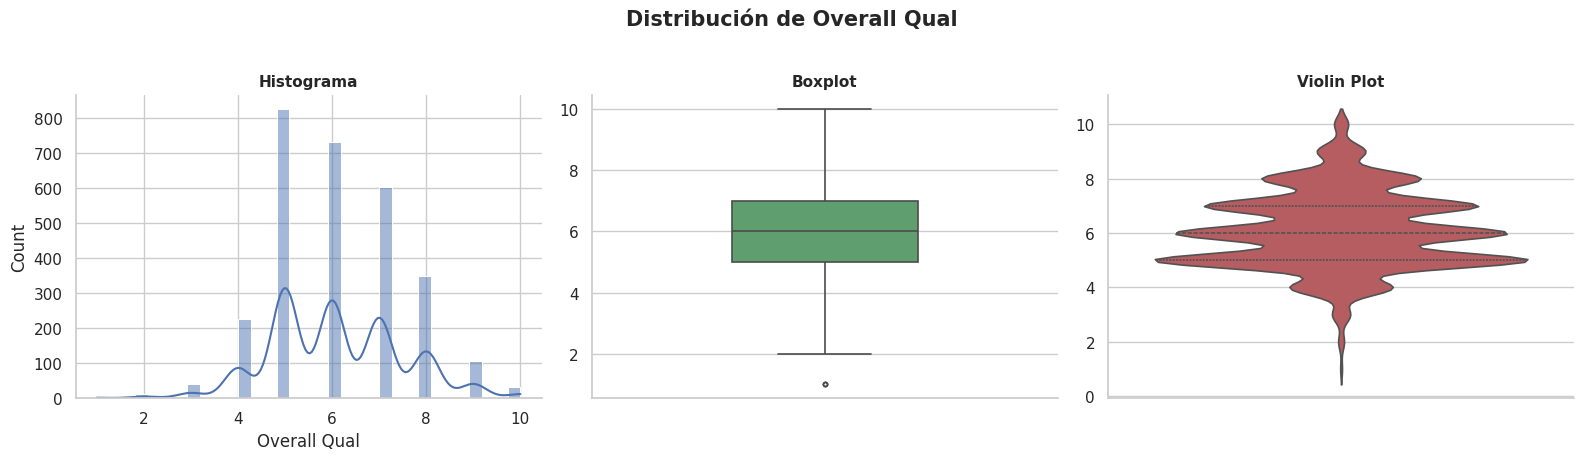

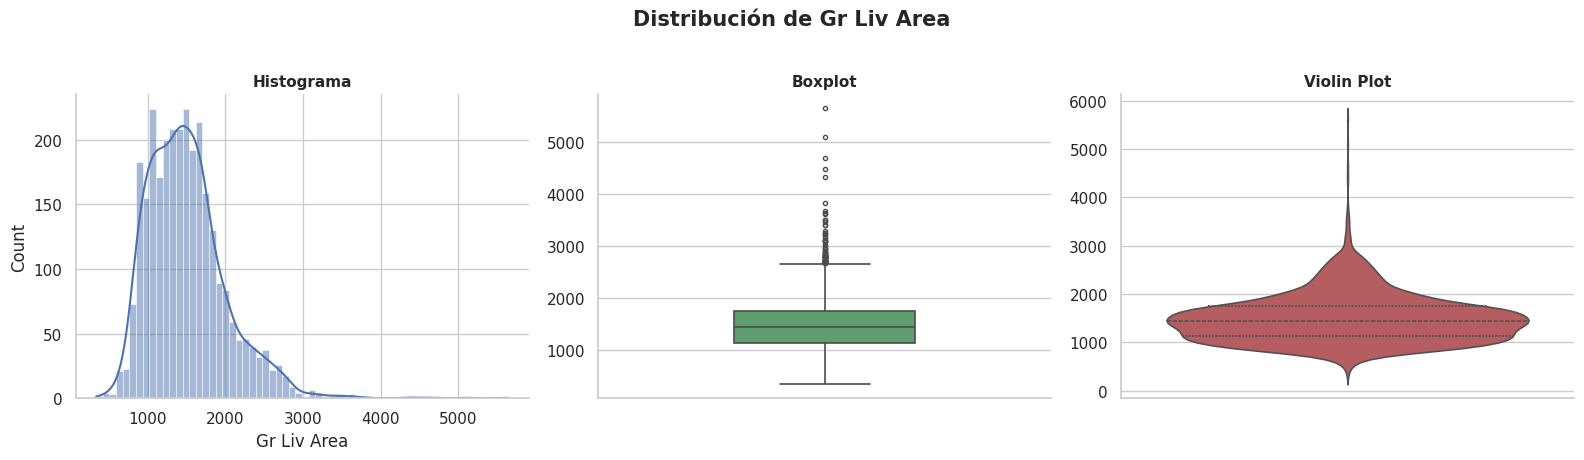

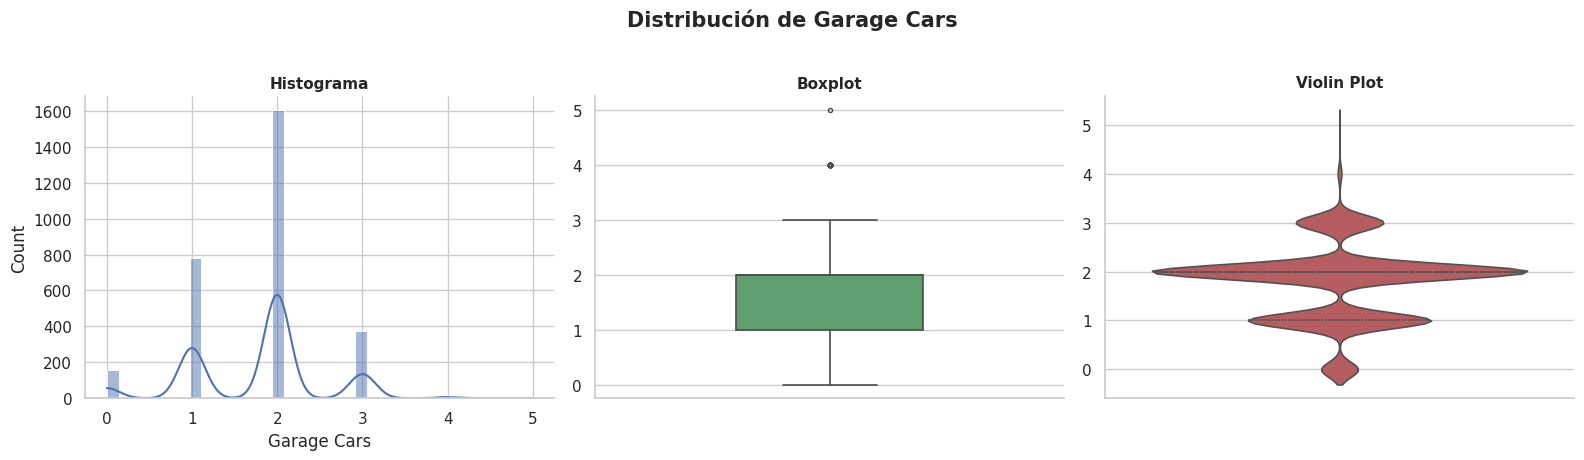

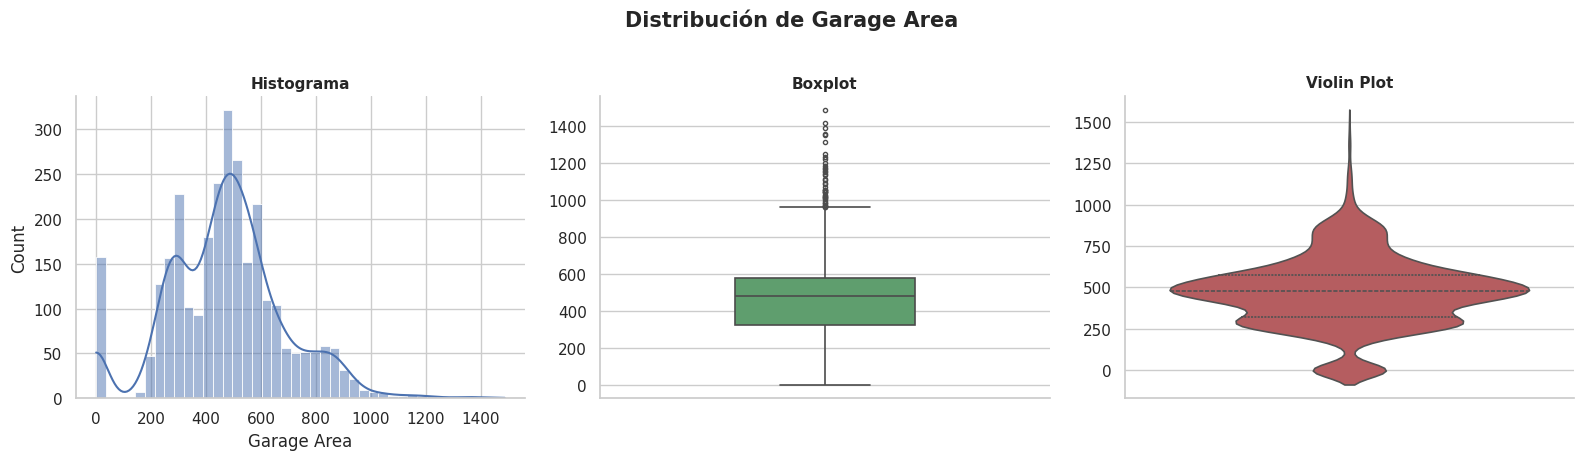

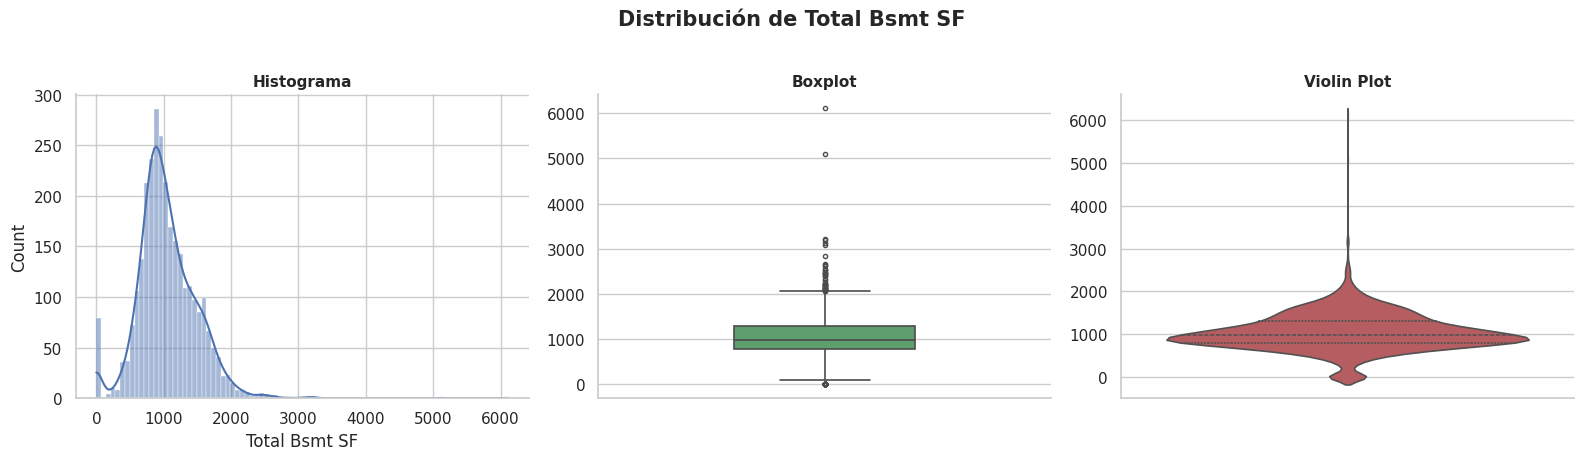

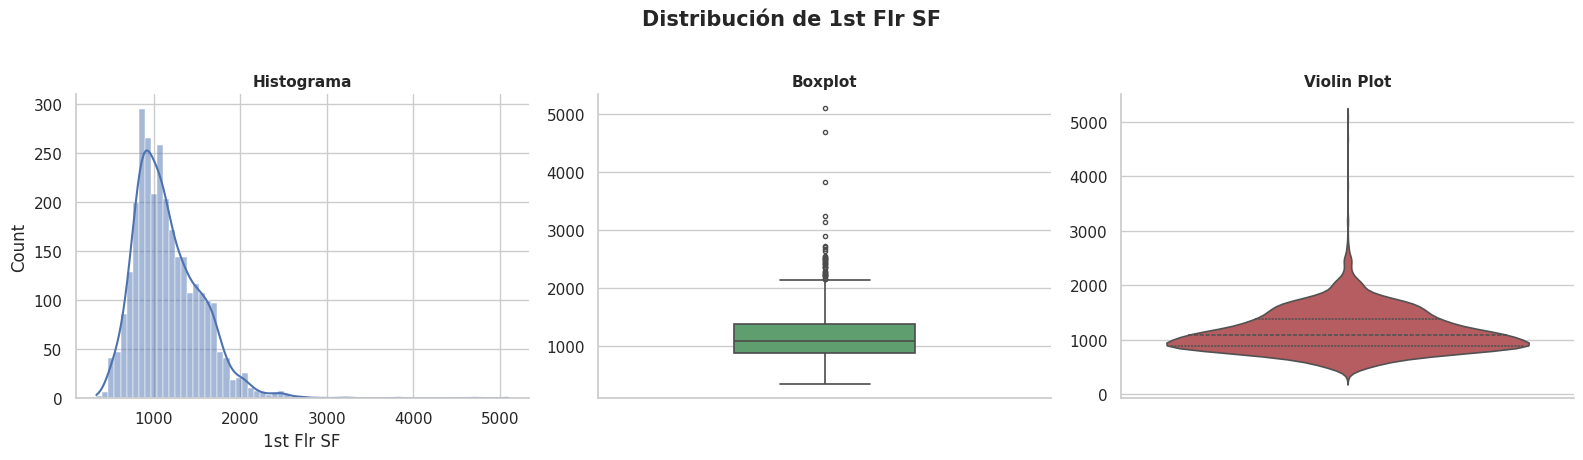

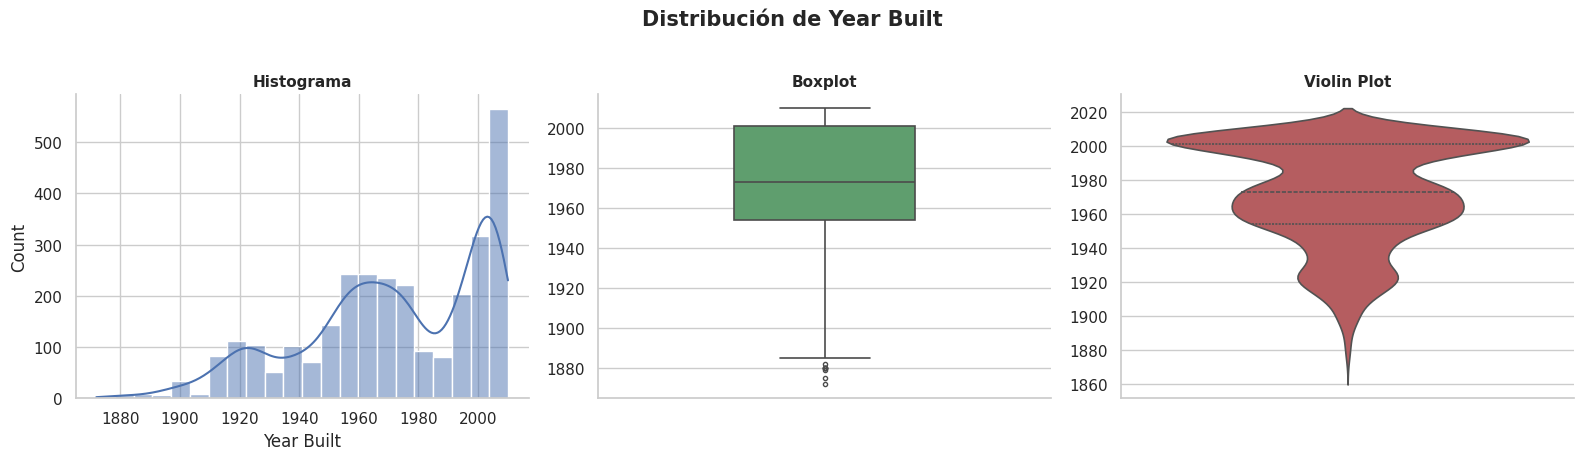

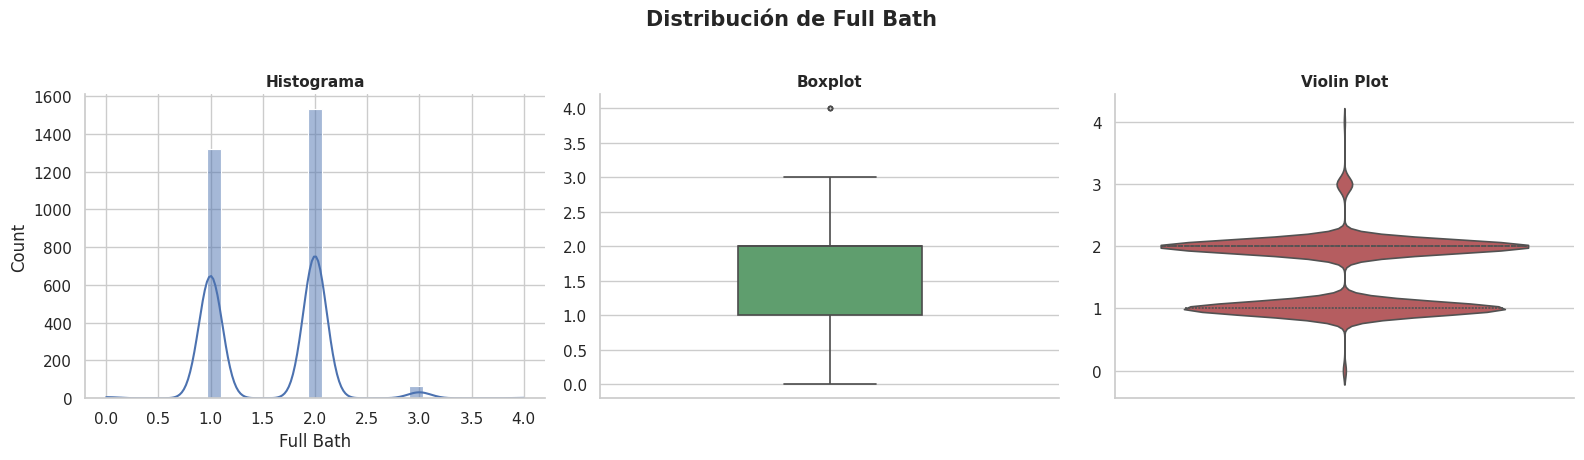

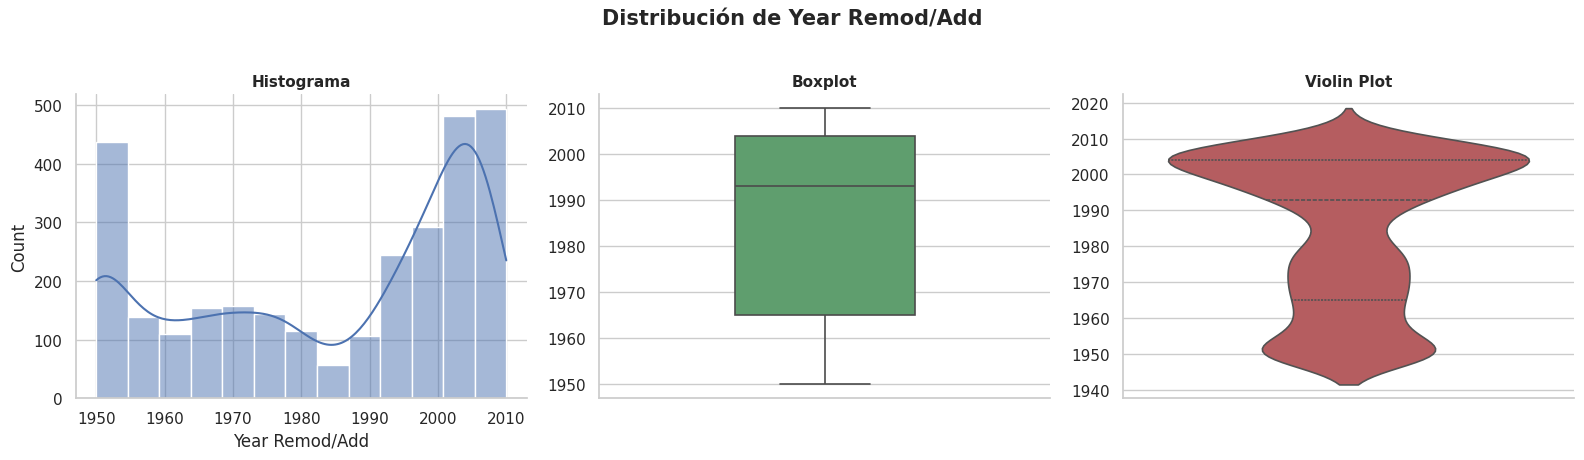

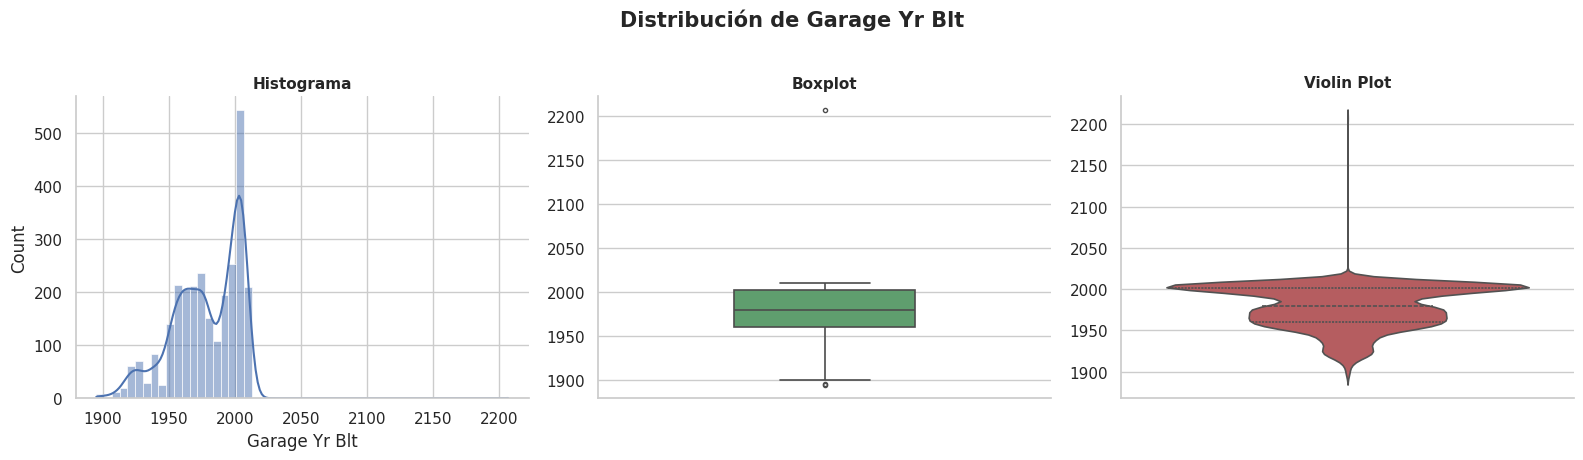

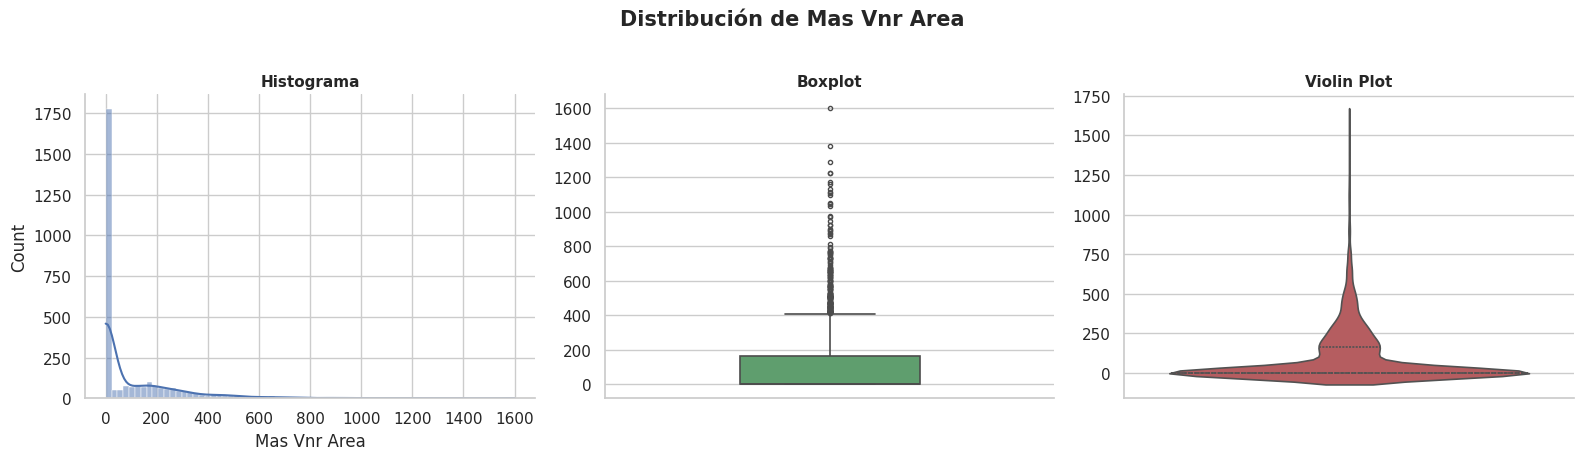

In [9]:
# Estilo moderno
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titleweight'] = 'bold'

variables = ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area',
             'Total Bsmt SF', '1st Flr SF', 'Year Built', 'Full Bath',
             'Year Remod/Add', 'Garage Yr Blt', 'Mas Vnr Area']

for var in variables:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle(f'Distribución de {var}', fontsize=15, fontweight='bold', y=1.02)

    # Histograma con KDE
    sns.histplot(data=df, x=var, kde=True, ax=axes[0], color='#4C72B0', edgecolor='white')
    axes[0].set_title('Histograma', fontsize=11)
    axes[0].set_xlabel(var)

    # Boxplot
    sns.boxplot(data=df, y=var, ax=axes[1], color='#55A868', width=0.4,
                fliersize=3, linewidth=1.2)
    axes[1].set_title('Boxplot', fontsize=11)
    axes[1].set_ylabel('')

    # Violin plot
    sns.violinplot(data=df, y=var, ax=axes[2], color='#C44E52', inner='quartile',
                    linewidth=1.2)
    axes[2].set_title('Violin Plot', fontsize=11)
    axes[2].set_ylabel('')

    sns.despine()
    plt.tight_layout()
    plt.show()

**Cantidad de nulos por columna y registros repetidos por fila**

In [10]:
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)

print("=== Valores nulos por columna ===")
print(nulos)

pct_nulos = (nulos / len(df) * 100).round(2)
print("\n=== % de nulos por columna ===")
print(pct_nulos)

dup_totales = df.duplicated().sum()
print(f"\n=== Duplicados totales (fila completa) ===\n{dup_totales}")


dup_pid = df['PID'].duplicated().sum()
print(f"\n=== Duplicados por PID ===\n{dup_pid}")

if dup_pid > 0:
    print("\nFilas con PID duplicado:")
    print(df[df['PID'].duplicated(keep=False)].sort_values('PID'))

=== Valores nulos por columna ===
Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64

=== % de nulos por columna ===
Pool QC          99.560
Misc Feature     96.380
Alley            93.240
Fence            80.480
Mas Vnr Type     60.580
Fireplace Qu     48.530
Lot Frontage     16.720
Garage Qual       5.430
Garage Cond       5.430
Garage Yr Blt     5.430
Garage Finish     5.430
Garage Type       5.360
Bsmt Exposur

**Significado de los nulos encontrados**

| Columna | Significado | ¿Qué es el NaN? |
|---|---|---|
| `Pool QC` | Calidad de la piscina (Ex, Gd, TA, Fa) | ✅ No tiene piscina — confirma con `Pool Area` = 0 |
| `Misc Feature` | Característica miscelánea no cubierta en otras columnas (cancha de tenis, cobertizo/`Shed`, ascensor, segundo garage, etc.) | ✅ No tiene ninguna característica especial — confirma con `Misc Val` = 0 |
| `Alley` | Tipo de acceso por callejón (Grvl=grava, Pave=pavimentado) | ✅ No tiene acceso por callejón (la mayoría de propiedades simplemente no colinda con uno) |
| `Fence` | Calidad de la cerca/reja (GdPrv, MnPrv, GdWo, MnWw) | ✅ No tiene cerca |
| `Mas Vnr Type` | Tipo de revestimiento de mampostería en fachada (BrkFace=ladrillo, Stone=piedra, None, BrkCmn) | ✅ No tiene revestimiento — pero ojo, aquí hay un matiz (ver nota abajo) |
| `Fireplace Qu` | Calidad de la(s) chimenea(s) | ✅ No tiene chimenea — confirma con `Fireplaces` = 0 |
| `Lot Frontage` | Metros lineales de calle conectados a la propiedad | ❌ Dato realmente faltante — toda propiedad tiene algún frontage, simplemente no se registró. Requiere imputación numérica (mediana, o mejor: mediana por `Neighborhood`) |
| `Garage Qual` | Calidad del garage | ✅ No tiene garage — confirma con `Garage Type` también nulo en las mismas filas |
| `Garage Cond` | Condición del garage | ✅ No tiene garage |
| `Garage Yr Blt` | Año de construcción del garage | ✅ No tiene garage (ya la vas a eliminar de todos modos por redundancia) |
| `Garage Finish` | Nivel de terminación interior del garage (Fin, RFn, Unf) | ✅ No tiene garage |
| `Garage Type` | Tipo de garage (Attchd, Detchd, BuiltIn, CarPort, etc.) | ✅ No tiene garage |
| `Bsmt Exposure` | Exposición del sótano a nivel de jardín (Gd, Av, Mn, No) | ✅ No tiene sótano |
| `BsmtFin Type 2` | Calidad del área terminada secundaria del sótano | ✅ No tiene sótano (o sótano sin segunda sección terminada) |
| `Bsmt Cond` | Condición general del sótano | ✅ No tiene sótano |
| `Bsmt Qual` | Calidad del sótano (altura) | ✅ No tiene sótano |
| `BsmtFin Type 1` | Calidad del área terminada principal del sótano | ✅ No tiene sótano |
| `Mas Vnr Area` | Área del revestimiento de mampostería (pies²) | ⚠️ Mixto — normalmente 0 cuando no hay revestimiento, pero hay inconsistencias con `Mas Vnr Type` (ver nota abajo) |

**Cantidad de Outliers**

In [11]:
df_num = df.select_dtypes(include=[np.number])
columnas = df_num.columns

def detectar_outliers_iqr(df, columnas):
    resumen = []
    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lim_inf = Q1 - 1.5 * IQR
        lim_sup = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)]
        n_outliers = len(outliers)
        pct_outliers = round(n_outliers / len(df) * 100, 2)

        resumen.append({
            'Variable': col,
            'Q1': round(Q1, 2),
            'Q3': round(Q3, 2),
            'IQR': round(IQR, 2),
            'Límite inferior': round(lim_inf, 2),
            'Límite superior': round(lim_sup, 2),
            'N° outliers': n_outliers,
            '% outliers': pct_outliers
        })

    return pd.DataFrame(resumen).sort_values('% outliers', ascending=False)

pd.set_option('display.max_rows', None)
resumen_outliers = detectar_outliers_iqr(df, columnas)
print(resumen_outliers.to_string(index=False))

       Variable            Q1            Q3           IQR  Límite inferior  Límite superior  N° outliers  % outliers
 Enclosed Porch         0.000         0.000         0.000            0.000            0.000          459      15.670
   BsmtFin SF 2         0.000         0.000         0.000            0.000            0.000          351      11.980
   Screen Porch         0.000         0.000         0.000            0.000            0.000          256       8.740
   Overall Cond         5.000         6.000         1.000            3.500            7.500          252       8.600
    MS SubClass        20.000        70.000        50.000          -55.000          145.000          208       7.100
   Mas Vnr Area         0.000       164.000       164.000         -246.000          410.000          200       6.830
   Lot Frontage        58.000        80.000        22.000           25.000          113.000          187       6.380
 Bsmt Half Bath         0.000         0.000         0.000       

**Exploracion de outliers**

**Variables con outliers mas relevantes***

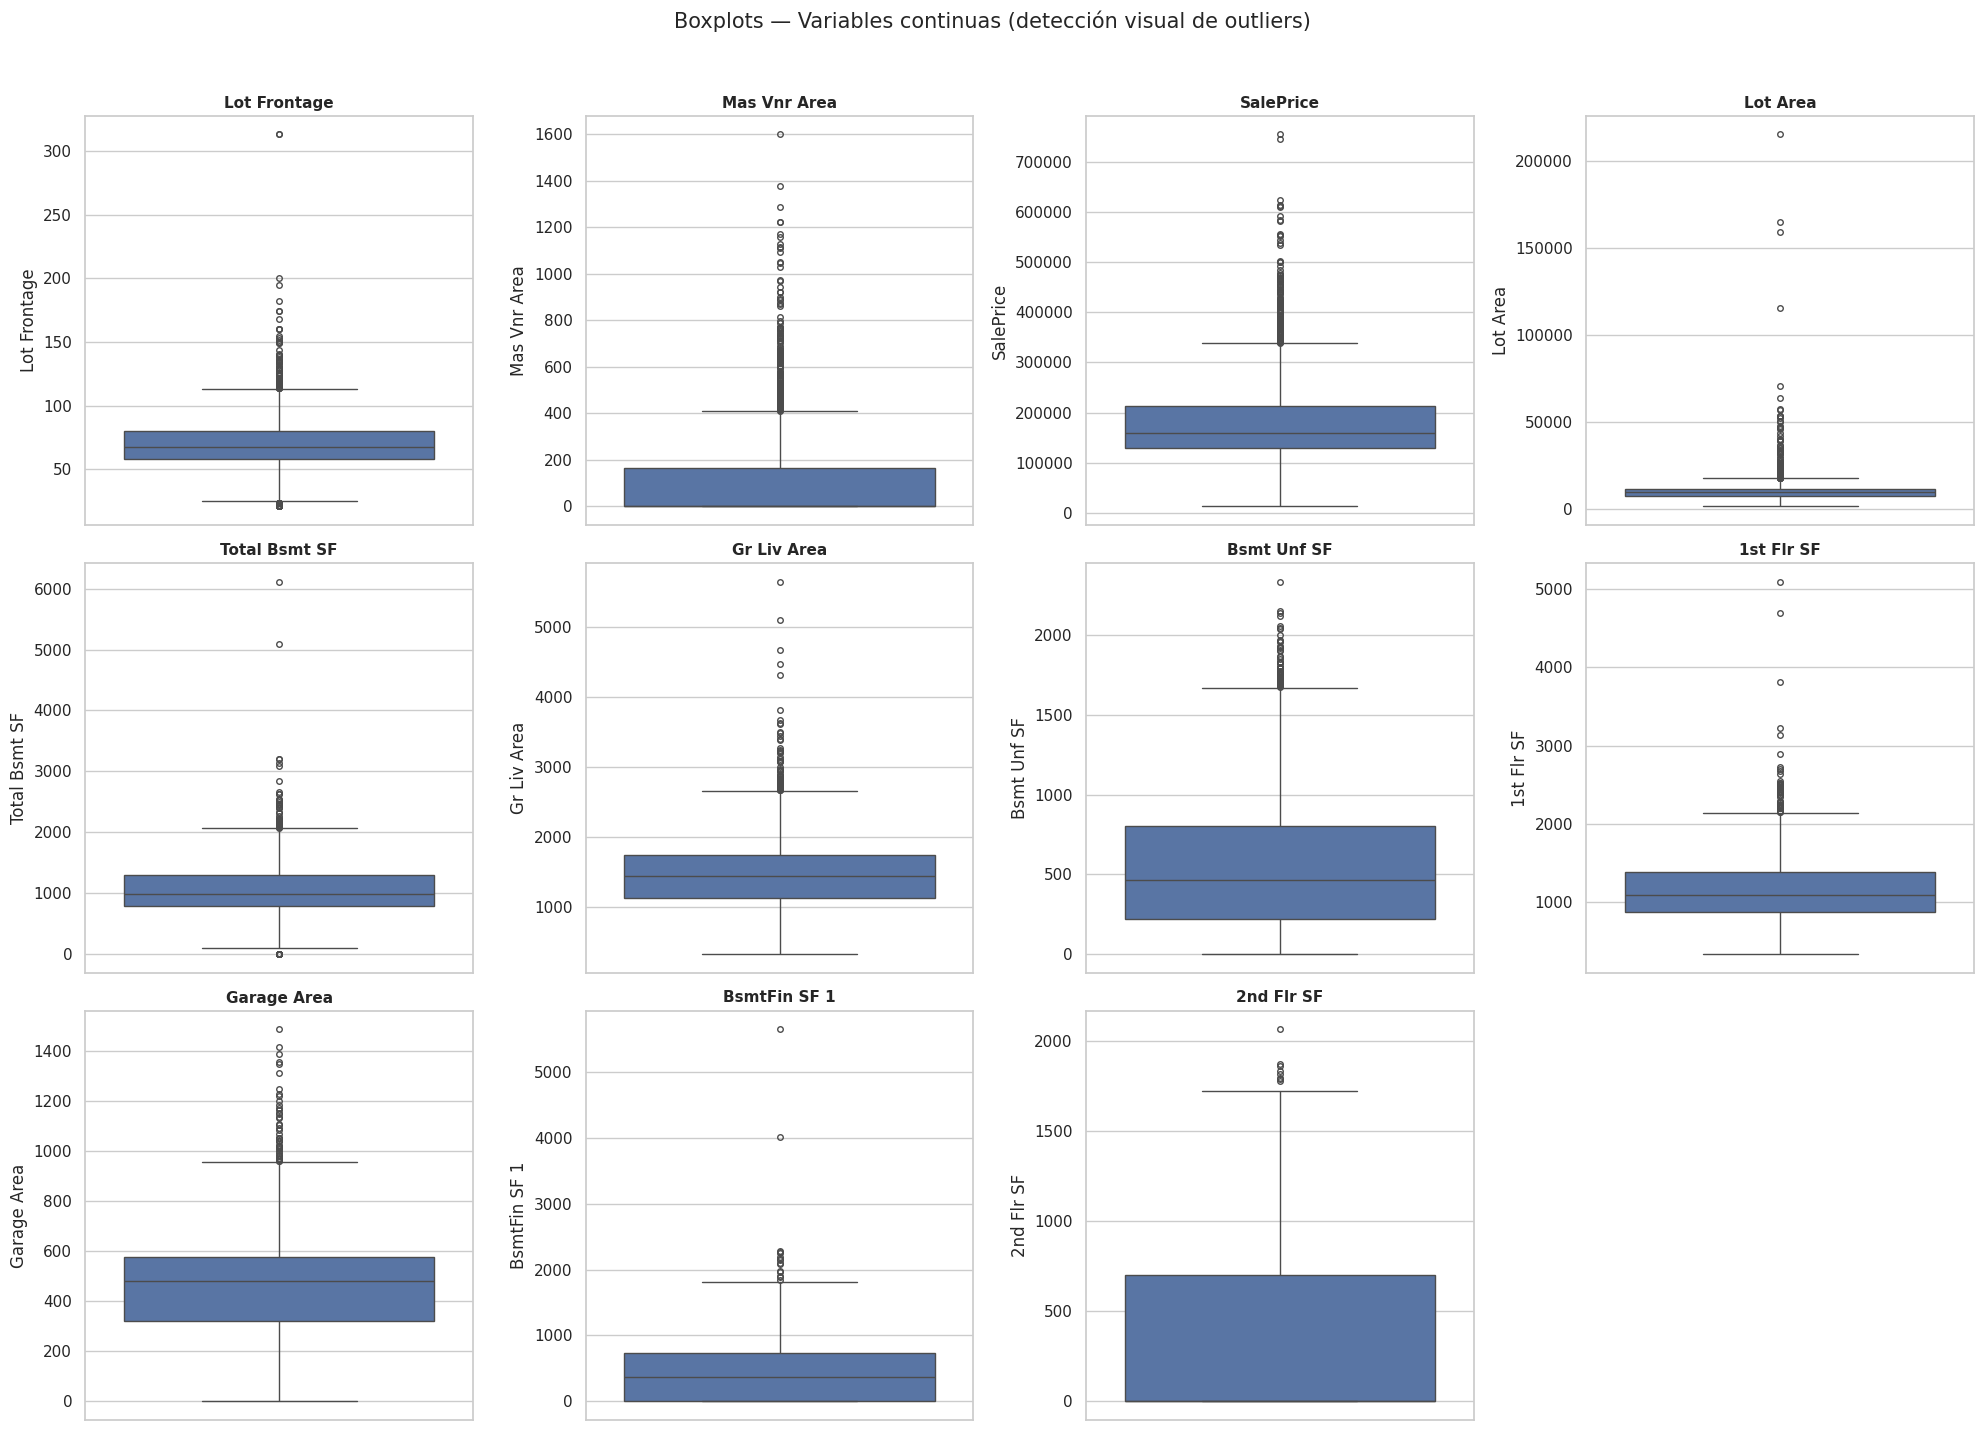

In [12]:
sns.set_theme(style="whitegrid")

variables_continuas = ['Lot Frontage', 'Mas Vnr Area', 'SalePrice', 'Lot Area',
                        'Total Bsmt SF', 'Gr Liv Area', 'Bsmt Unf SF', '1st Flr SF',
                        'Garage Area', 'BsmtFin SF 1', '2nd Flr SF']

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(variables_continuas):
    sns.boxplot(data=df, y=col, ax=axes[i], color='#4C72B0', fliersize=4)
    axes[i].set_title(col, fontsize=11)

axes[-1].axis('off')

plt.suptitle('Boxplots — Variables continuas (detección visual de outliers)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

**Variables discretas/ordinales de rango acotado**

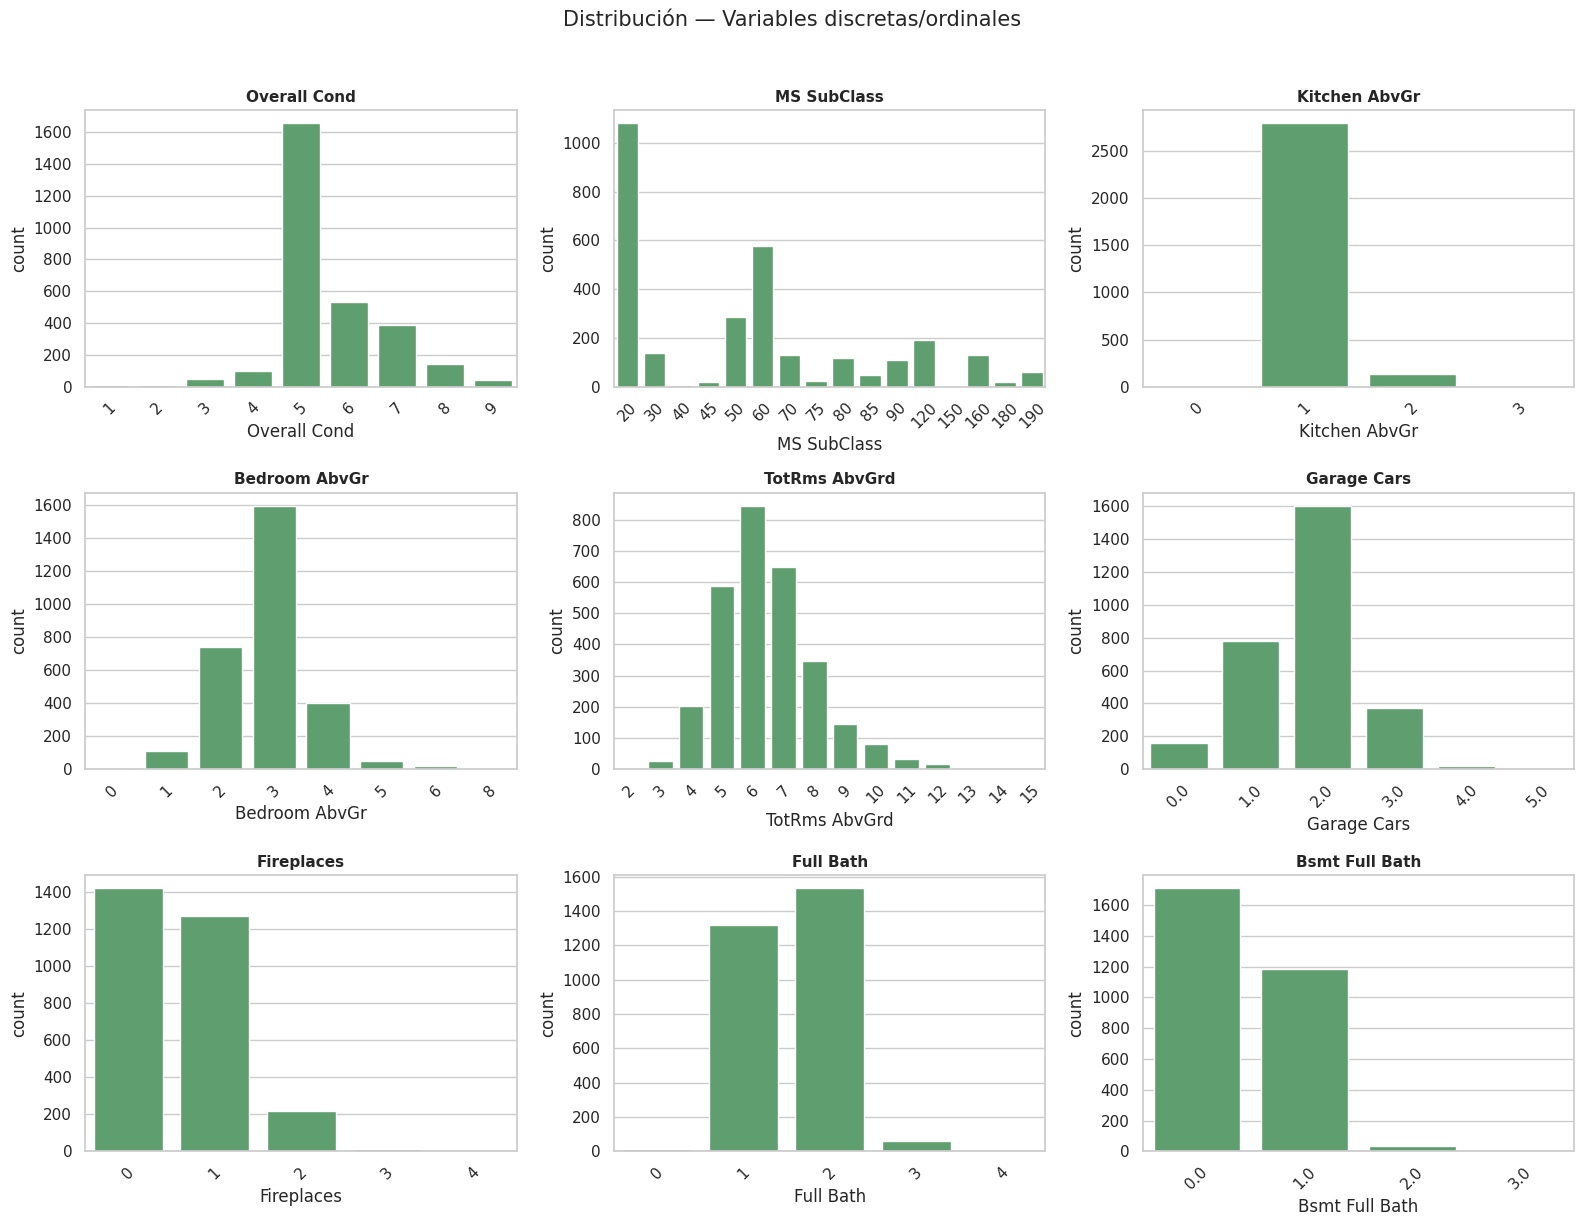

In [13]:
variables_discretas = ['Overall Cond', 'MS SubClass', 'Kitchen AbvGr',
                        'Bedroom AbvGr', 'TotRms AbvGrd', 'Garage Cars',
                        'Fireplaces', 'Full Bath', 'Bsmt Full Bath']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(variables_discretas):
    sns.countplot(data=df, x=col, ax=axes[i], color='#55A868')
    axes[i].set_title(col, fontsize=11)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Distribución — Variables discretas/ordinales', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

**Variables dispersas**

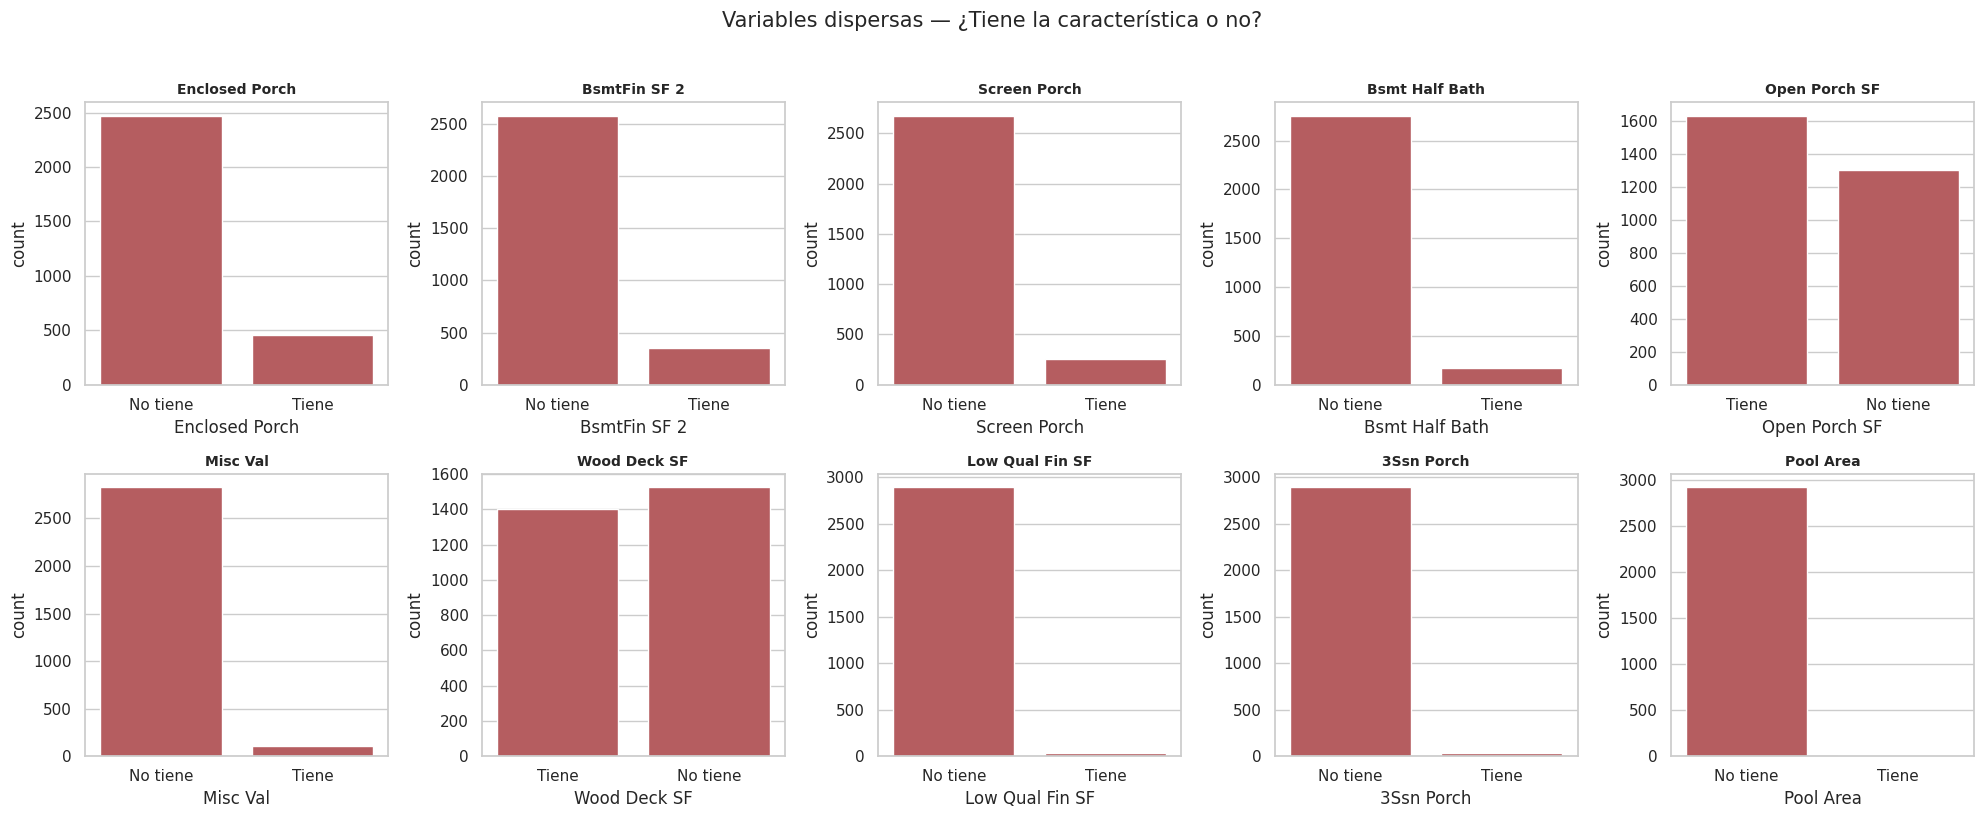

In [14]:
variables_dispersas = ['Enclosed Porch', 'BsmtFin SF 2', 'Screen Porch', 'Bsmt Half Bath',
                        'Open Porch SF', 'Misc Val', 'Wood Deck SF', 'Low Qual Fin SF',
                        '3Ssn Porch', 'Pool Area']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(variables_dispersas):
    tiene = (df[col] > 0).map({True: 'Tiene', False: 'No tiene'})
    sns.countplot(x=tiene, ax=axes[i], color='#C44E52')
    axes[i].set_title(col, fontsize=10)

plt.suptitle('Variables dispersas — ¿Tiene la característica o no?', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [15]:
casos_atipicos = df[df['Gr Liv Area'] > 4000][['Gr Liv Area', 'SalePrice', 'Overall Qual']]
print(casos_atipicos.sort_values('Gr Liv Area', ascending=False))

      Gr Liv Area  SalePrice  Overall Qual
1498         5642     160000            10
2180         5095     183850            10
2181         4676     184750            10
1760         4476     745000            10
1767         4316     755000            10


In [16]:
print(df.loc[[1498, 2180, 2181, 1760, 1767], ['Gr Liv Area', 'SalePrice', 'Overall Qual', 'Sale Condition', 'Sale Type']])

      Gr Liv Area  SalePrice  Overall Qual Sale Condition Sale Type
1498         5642     160000            10        Partial       New
2180         5095     183850            10        Partial       New
2181         4676     184750            10        Partial       New
1760         4476     745000            10        Abnorml       WD 
1767         4316     755000            10         Normal       WD 


In [17]:
# Trabajar sobre una copia para no modificar el df original
df_clean = df.copy()

# Eliminar las 5 propiedades con Gr Liv Area > 4000 (criterio del autor original del dataset)
indices_a_eliminar = df_clean[df_clean['Gr Liv Area'] > 4000].index.tolist()
print(f"Índices a eliminar: {indices_a_eliminar}")

df_clean = df_clean.drop(index=indices_a_eliminar).reset_index(drop=True)
print(f"Filas eliminadas: {len(indices_a_eliminar)}")
print(f"Tamaño original: {df.shape} → Tamaño limpio: {df_clean.shape}")

Índices a eliminar: [1498, 1760, 1767, 2180, 2181]
Filas eliminadas: 5
Tamaño original: (2930, 82) → Tamaño limpio: (2925, 82)


**Análisis y Tratamiento de Outliers**

**Metodología:** se calculó el rango intercuartílico (IQR) para las 39 variables numéricas del dataset, y en lugar de aplicar una regla de eliminación automática, cada grupo de variables se evaluó según su naturaleza antes de decidir una acción.

**1. Clasificación de variables según el tipo de "outlier" detectado**

| Grupo | Ejemplos | Diagnóstico |
|---|---|---|
| Dispersas (Q1=Q3=0) | `Pool Area`, `Misc Val`, `3Ssn Porch`, `Screen Porch` | El IQR marca como "outlier" simplemente tener la característica (ej. tener piscina). No son anomalías, son variables cuasi-binarias. |
| Discretas/ordinales | `Bedroom AbvGr`, `TotRms AbvGrd`, `MS SubClass` | Outliers técnicos por IQR, pero corresponden a conteos razonables y reales (ej. una casa con 8 dormitorios es rara pero válida). |
| Continuas | `SalePrice`, `Lot Area`, `Total Bsmt SF`, `Garage Area`, etc. | Colas largas graduales, esperables en variables de superficie. No se detectaron saltos abruptos, salvo en `Gr Liv Area`. |

**2. Caso identificado: `Gr Liv Area`**

Se detectaron 5 propiedades con superficie habitable > 4000 pies², claramente separadas del resto de la distribución.

**3. Validación cruzada antes de decidir**

Se cruzaron estas 5 observaciones con `SalePrice`, `Overall Qual`, `Sale Condition` y `Sale Type`:

| Índice | Gr Liv Area | SalePrice | Overall Qual | Sale Condition | Sale Type |
|---|---|---|---|---|---|
| 1498 | 5642 | 160,000 | 10 | Partial | New |
| 2180 | 5095 | 183,850 | 10 | Partial | New |
| 2181 | 4676 | 184,750 | 10 | Partial | New |
| 1760 | 4476 | 745,000 | 10 | Abnorml | WD |
| 1767 | 4316 | 755,000 | 10 | Normal | WD |

Las 5 presentan condiciones de venta no estándar (preventas de construcción incompleta o ventas anormales), lo que explica por qué su precio no guarda relación coherente con su superficie y calidad — no se trata de casas grandes y caras "normales", sino de transacciones atípicas.

**4. Decisión**

Siguiendo el criterio del autor original del dataset (De Cock, 2011), se eliminaron las 5 observaciones por representar transacciones no representativas del comportamiento estándar de mercado, ya que podrían distorsionar el ajuste del modelo. El resto de las variables con outliers "normales" (dispersas, discretas, y continuas sin evidencia de anomalía) se mantuvieron sin modificación, ya que reflejan variabilidad real del mercado inmobiliario y no errores de datos.

**Conclusión:** la eliminación de outliers no se aplicó de forma automática según el criterio IQR, sino únicamente tras validar con evidencia cruzada (precio, calidad, condición de venta) que las observaciones carecían de justificación de mercado.

----------------------------------------------------------------------------------------

**Tratamiento de Valores Nulos (Imputación)**

El diagnóstico previo mostró que la gran mayoría de los nulos del dataset **no son datos perdidos**, sino ausencia de la característica. Por eso no se aplica una estrategia única, sino un criterio por grupo:

| Grupo | Columnas | Criterio | Justificación |
|---|---|---|---|
| Categóricas de ausencia | `Pool QC`, `Misc Feature`, `Alley`, `Fence`, `Fireplace Qu`, grupo garage y grupo sótano | Rellenar con el string `"None"` | El NaN es informativo: significa "no tiene". Se convierte en una categoría explícita para no perder esa información ni eliminar filas. Validado cruzando con sus columnas numéricas compañeras (ej. `Pool Area` = 0 cuando `Pool QC` es nulo). |
| Dato genuinamente faltante | `Lot Frontage` (490 nulos) | Mediana por `Neighborhood`, con mediana global como respaldo | Toda propiedad tiene frente de lote; el dato simplemente no se registró. El frente depende del trazado urbano de cada barrio, por lo que la mediana local es un estimador mucho menos sesgado que la global. |
| Numéricas compañeras | `Garage Cars`, `Garage Area`, `Total Bsmt SF`, `BsmtFin SF 1`, `BsmtFin SF 2`, `Bsmt Unf SF`, `Bsmt Full Bath`, `Bsmt Half Bath` | Rellenar con `0` | Son 1-2 nulos por columna, correspondientes a casas sin garage o sin sótano. El 0 es el valor semánticamente correcto (superficie inexistente), no una imputación estadística. |
| Caso mixto | `Mas Vnr Type`, `Mas Vnr Area` | Área → 0; tipo → moda si el área > 0, `"None"` en el resto | Se revisó la consistencia entre ambas antes de decidir (ver celda de diagnóstico). |
| Redundante | `Garage Yr Blt` (159 nulos) | Rellenar con `Year Built` | Candidata a eliminación posterior por multicolinealidad con `Year Built` (corr = 0.835). Se imputa igualmente para dejar el dataset sin nulos, pero el criterio no afecta al modelo final. |
| Nulo aislado | `Electrical` (1 nulo) | Moda (`SBrkr`) | Un solo registro sobre 2925; la moda es el criterio de mínimo impacto. |

**Nota sobre la imputación por barrio:** dos barrios (`GrnHill` y `Landmrk`, 3 propiedades en total) no tienen **ningún** registro de `Lot Frontage`, por lo que su mediana local es nula. **En esos casos se aplica la mediana global como respaldo.**

**1. Diagnóstico previo del caso mixto `Mas Vnr Type` / `Mas Vnr Area`**

Mas Vnr Type → el tipo de revestimiento (BrkFace, Stone, BrkCmn…)

Mas Vnr Area → cuántos pies² de fachada lo tienen

In [18]:
# Antes de imputar, verificar la consistencia entre el tipo y el área de revestimiento
tipo_nulo = df_clean['Mas Vnr Type'].isnull()

print("=== Consistencia Mas Vnr Type vs Mas Vnr Area ===")
print(f"Type nulo y Area > 0     : {(tipo_nulo & (df_clean['Mas Vnr Area'] > 0)).sum()}")
print(f"Type nulo y Area = 0     : {(tipo_nulo & (df_clean['Mas Vnr Area'] == 0)).sum()}")
print(f"Type nulo y Area también nulo: {(tipo_nulo & df_clean['Mas Vnr Area'].isnull()).sum()}")

print("\n=== Filas inconsistentes (sin tipo pero con área declarada) ===")
print(df_clean.loc[tipo_nulo & (df_clean['Mas Vnr Area'] > 0), ['Mas Vnr Type', 'Mas Vnr Area']])

=== Consistencia Mas Vnr Type vs Mas Vnr Area ===
Type nulo y Area > 0     : 7
Type nulo y Area = 0     : 1744
Type nulo y Area también nulo: 23

=== Filas inconsistentes (sin tipo pero con área declarada) ===
     Mas Vnr Type  Mas Vnr Area
363           NaN       344.000
403           NaN       312.000
441           NaN       285.000
1858          NaN         1.000
1910          NaN         1.000
2000          NaN         1.000
2523          NaN       288.000


Ambas columnas describen lo mismo (revestimiento de fachada) pero tienen distinta cantidad de nulos (1774 vs 23), señal de que se contradicen en algunas filas.
Antes de imputar se cuenta cuántas filas caen en cada situación, para no asignar `"None"` a casas que sí declaran área de revestimiento.
Esta celda solo diagnostica: no modifica el dataset.

**2. Categóricas donde el NaN significa "no tiene la característica"**

In [19]:
# Columnas donde el NaN es informativo: la propiedad no tiene esa característica
cat_none = [
    # Características opcionales de la propiedad
    'Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu',
    # Grupo garage
    'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
    # Grupo sótano
    'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2'
]

nulos_antes = df_clean[cat_none].isnull().sum()

# Se convierte el NaN en una categoría explícita "None"
df_clean[cat_none] = df_clean[cat_none].fillna('None')

print("=== Imputación de categóricas con 'None' ===")
print(pd.DataFrame({
    'Nulos antes': nulos_antes,
    'Nulos después': df_clean[cat_none].isnull().sum()
}))

=== Imputación de categóricas con 'None' ===
                Nulos antes  Nulos después
Pool QC                2914              0
Misc Feature           2820              0
Alley                  2727              0
Fence                  2354              0
Fireplace Qu           1422              0
Garage Type             157              0
Garage Finish           159              0
Garage Qual             159              0
Garage Cond             159              0
Bsmt Qual                80              0
Bsmt Cond                80              0
Bsmt Exposure            83              0
BsmtFin Type 1           80              0
BsmtFin Type 2           81              0


En estas 14 columnas el NaN no es un dato perdido: codifica la ausencia de la característica (sin piscina, sin garage, sin sótano).
Se validó cruzando con sus columnas numéricas compañeras, que valen 0 en las mismas filas (ej. `Pool Area` = 0 cuando `Pool QC` es nulo).
Se reemplaza por la categoría explícita `"None"` para conservar esa información sin eliminar filas ni columnas.

**2. `Lot Frontage` — imputación por mediana de barrio**

In [20]:
# Mediana global como respaldo (barrios que no tienen ningún dato registrado)
mediana_global = df_clean['Lot Frontage'].median()

# Barrios sin ningún registro de Lot Frontage
barrios_sin_dato = df_clean.groupby('Neighborhood')['Lot Frontage'].apply(lambda s: s.notna().sum() == 0)
print("=== Barrios sin ningún dato de Lot Frontage (usarán la mediana global) ===")
print(barrios_sin_dato[barrios_sin_dato].index.tolist())

print(f"\nNulos antes: {df_clean['Lot Frontage'].isnull().sum()}")

# Mediana del barrio alineada fila a fila y, si el barrio no tiene mediana, mediana global
mediana_barrio = df_clean.groupby('Neighborhood')['Lot Frontage'].transform('median')
df_clean['Lot Frontage'] = df_clean['Lot Frontage'].fillna(mediana_barrio).fillna(mediana_global)

print(f"Nulos después: {df_clean['Lot Frontage'].isnull().sum()}")
print(f"Mediana global usada como respaldo: {mediana_global}")

=== Barrios sin ningún dato de Lot Frontage (usarán la mediana global) ===
['GrnHill', 'Landmrk']

Nulos antes: 490
Nulos después: 0
Mediana global usada como respaldo: 68.0


Es el único caso de dato genuinamente faltante: toda propiedad tiene frente de lote, simplemente no se registró en 490 filas.
El frente depende del trazado urbano de cada barrio, por lo que la mediana por `Neighborhood` es un estimador menos sesgado que la global.
Dos barrios (`GrnHill` y `Landmrk`) no tienen ningún registro, así que se aplica la mediana global como respaldo en esas 3 filas.

**3. Numéricas compañeras del garage y del sótano**

In [21]:
# Nulos aislados (1-2 por columna) que corresponden a casas sin garage o sin sótano
num_cero = [
    'Garage Cars', 'Garage Area',
    'Total Bsmt SF', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
    'Bsmt Full Bath', 'Bsmt Half Bath'
]

nulos_antes = df_clean[num_cero].isnull().sum()

# El 0 es el valor semánticamente correcto: superficie/conteo de algo que no existe
df_clean[num_cero] = df_clean[num_cero].fillna(0)

print("=== Imputación de numéricas con 0 ===")
print(pd.DataFrame({
    'Nulos antes': nulos_antes,
    'Nulos después': df_clean[num_cero].isnull().sum()
}))

=== Imputación de numéricas con 0 ===
                Nulos antes  Nulos después
Garage Cars               1              0
Garage Area               1              0
Total Bsmt SF             1              0
BsmtFin SF 1              1              0
BsmtFin SF 2              1              0
Bsmt Unf SF               1              0
Bsmt Full Bath            2              0
Bsmt Half Bath            2              0


Son 1 o 2 nulos por columna, correspondientes a viviendas sin garage o sin sótano.
El 0 no es una imputación estadística sino el valor semánticamente correcto: la superficie de algo que no existe.
Mantiene además la coherencia con las categóricas del mismo grupo, ya rellenadas con `"None"`.

**4. `Mas Vnr Type` y `Mas Vnr Area`

In [22]:
# El área nula se interpreta como ausencia de revestimiento
df_clean['Mas Vnr Area'] = df_clean['Mas Vnr Area'].fillna(0)

# Las 7 filas con área declarada pero sin tipo se imputan con la moda de los tipos existentes
moda_mas_vnr = df_clean['Mas Vnr Type'].mode()[0]
con_area_sin_tipo = df_clean['Mas Vnr Type'].isnull() & (df_clean['Mas Vnr Area'] > 0)
df_clean.loc[con_area_sin_tipo, 'Mas Vnr Type'] = moda_mas_vnr

# El resto (área = 0) sí corresponde a "no tiene revestimiento"
df_clean['Mas Vnr Type'] = df_clean['Mas Vnr Type'].fillna('None')

print(f"=== Imputación Mas Vnr (moda usada: {moda_mas_vnr}) ===")
print(f"Filas corregidas con la moda: {con_area_sin_tipo.sum()}")
print(f"\nNulos restantes → Type: {df_clean['Mas Vnr Type'].isnull().sum()} | "
      f"Area: {df_clean['Mas Vnr Area'].isnull().sum()}")
print("\nDistribución final de Mas Vnr Type:")
print(df_clean['Mas Vnr Type'].value_counts())

=== Imputación Mas Vnr (moda usada: BrkFace) ===
Filas corregidas con la moda: 7

Nulos restantes → Type: 0 | Area: 0

Distribución final de Mas Vnr Type:
Mas Vnr Type
None       1767
BrkFace     886
Stone       246
BrkCmn       25
CBlock        1
Name: count, dtype: int64


El área nula (23 filas) se interpreta como ausencia de revestimiento, coherente con que su tipo también sea nulo.
Las 7 filas con área declarada pero sin tipo son inconsistencias reales: se imputan con la moda (`BrkFace`) en lugar de `"None"`, porque su propia área confirma que sí tienen revestimiento.
El resto (1744 filas con área 0) sí corresponde a "no tiene" y se rellena con `"None"`.

**5. `Garage Yr Blt` y `Electrical`**

Garage Yr Blt: se imputa con Year Built (en casas sin garage el año de referencia, es el de la vivienda). Es candidata a eliminación posterior por multicolinealidad con Year Built (corr = 0.835)

In [24]:

df_clean['Garage Yr Blt'] = df_clean['Garage Yr Blt'].fillna(df_clean['Year Built'])

# Electrical: un único nulo → moda
moda_electrical = df_clean['Electrical'].mode()[0]
df_clean['Electrical'] = df_clean['Electrical'].fillna(moda_electrical)

print(f"=== Garage Yr Blt → nulos restantes: {df_clean['Garage Yr Blt'].isnull().sum()} ===")
print(f"=== Electrical → imputado con la moda '{moda_electrical}', "
      f"nulos restantes: {df_clean['Electrical'].isnull().sum()} ===")

=== Garage Yr Blt → nulos restantes: 0 ===
=== Electrical → imputado con la moda 'SBrkr', nulos restantes: 0 ===


`Electrical` tiene un único nulo sobre 2925 registros: la moda (`SBrkr`) es el criterio de mínimo impacto.

**Verificación final: dataset sin nulos**

In [25]:
total_nulos = df_clean.isnull().sum().sum()

print("=== Verificación final de nulos ===")
print(f"Total de nulos en df_clean: {total_nulos}")

if total_nulos == 0:
    print("No quedan valores nulos en df_clean")
else:
    print("Columnas con nulos pendientes:")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

print(f"\nDimensiones finales: {df_clean.shape}")

=== Verificación final de nulos ===
Total de nulos en df_clean: 0
No quedan valores nulos en df_clean

Dimensiones finales: (2925, 82)


**Preparación de Datos — Creación de Flags y Eliminación de Identificadores**

**1. Variables flag binarias**

In [26]:
# Diccionario: nombre del flag → columna numérica que confirma la existencia de la característica
flags = {
    'Tiene_Piscina':  'Pool Area',
    'Tiene_Sotano':   'Total Bsmt SF',
    'Tiene_Garage':   'Garage Area',
    'Tiene_Chimenea': 'Fireplaces'
}

# 1 = la propiedad tiene la característica, 0 = no la tiene
for flag, col in flags.items():
    df_clean[flag] = (df_clean[col] > 0).astype(int)

print("=== Flags binarios creados ===")
resumen_flags = pd.DataFrame({
    'Columna base': flags.values(),
    'N° con la característica': [df_clean[f].sum() for f in flags],
    '% del total': [round(df_clean[f].mean() * 100, 2) for f in flags]
}, index=flags.keys())
print(resumen_flags)

print(f"\nDimensiones tras crear los flags: {df_clean.shape}")

=== Flags binarios creados ===
                 Columna base  N° con la característica  % del total
Tiene_Piscina       Pool Area                        11        0.380
Tiene_Sotano    Total Bsmt SF                      2845       97.260
Tiene_Garage      Garage Area                      2767       94.600
Tiene_Chimenea     Fireplaces                      1503       51.380

Dimensiones tras crear los flags: (2925, 86)


En el encoding ordinal posterior, la categoría `"None"` se mapea a 0, lo que haría indistinguible "no tiene piscina" de "piscina de pésima calidad".
Estos flags separan explícitamente la **existencia** de la característica de su **calidad**, permitiendo que el modelo aprenda ambos efectos por separado.
Se construyen desde las columnas numéricas (`Pool Area`, `Total Bsmt SF`, `Garage Area`, `Fireplaces`), que son la fuente más fiable de la existencia.

** 2. Eliminación de identificadores administrativos**

In [27]:
# Identificadores administrativos: no aportan información predictiva sobre el precio
identificadores = ['Order', 'PID']

print("=== Correlaciones espurias detectadas en el EDA ===")
print(f"PID vs SalePrice : {df_clean['PID'].corr(df_clean['SalePrice']):.3f}")
print(f"Order vs Yr Sold : {df_clean['Order'].corr(df_clean['Yr Sold']):.3f}")

df_clean = df_clean.drop(columns=identificadores)

print(f"\nColumnas eliminadas: {identificadores}")
print(f"Dimensiones finales: {df_clean.shape}")
print(f"¿Quedan identificadores? {[c for c in identificadores if c in df_clean.columns] or 'No'}")

=== Correlaciones espurias detectadas en el EDA ===
PID vs SalePrice : -0.246
Order vs Yr Sold : -0.976

Columnas eliminadas: ['Order', 'PID']
Dimensiones finales: (2925, 84)
¿Quedan identificadores? No


- corr espurias: Una correlación espuria es una asociación estadística entre dos variables que no responde a una relación causal entre ellas.

**Tratamiento de Multicolinealidad**

**1. Copia de respaldo para el análisis de clustering**

In [28]:
# Copia íntegra antes de podar variables: se usará en el análisis de sesgo con K-Means,
# donde interesa el perfil completo de cada propiedad y no la independencia entre predictores
df_completo = df_clean.copy()

print("=== Copia de respaldo creada ===")
print(f"df_completo: {df_completo.shape}")
print(f"df_clean   : {df_clean.shape}")

=== Copia de respaldo creada ===
df_completo: (2925, 84)
df_clean   : (2925, 84)


La multicolinealidad solo es un problema para los modelos de regresión, donde variables redundantes distorsionan la interpretación de los coeficientes.
K-Means, en cambio, agrupa por similitud global entre observaciones, así que conservar el conjunto completo de atributos es deseable para caracterizar los clusters.
Por eso se congela `df_completo` antes de podar; a partir de aquí solo se modifica `df_clean`.

**2. Diagnóstico: correlación de las variables en conflicto con `SalePrice`**

In [30]:
# Variables involucradas en los pares redundantes detectados en el EDA
variables_conflicto = [
    'Garage Cars', 'Garage Area',
    'Year Built', 'Garage Yr Blt',
    'Gr Liv Area', 'TotRms AbvGrd',
    'Total Bsmt SF', '1st Flr SF',
    'Bedroom AbvGr', '2nd Flr SF'
]

# Criterio de decisión: ante dos variables redundantes se conserva la que más correlaciona
# con la variable objetivo
corr_objetivo = df_clean[variables_conflicto + ['SalePrice']].corr()['SalePrice'].drop('SalePrice')

print("=== Correlación con SalePrice de cada variable en conflicto ===")
print(corr_objetivo.sort_values(ascending=False).round(3))

=== Correlación con SalePrice de cada variable en conflicto ===
Gr Liv Area     0.719
Total Bsmt SF   0.659
Garage Cars     0.652
Garage Area     0.648
1st Flr SF      0.643
Year Built      0.565
Garage Yr Blt   0.547
TotRms AbvGrd   0.498
2nd Flr SF      0.257
Bedroom AbvGr   0.140
Name: SalePrice, dtype: float64


Cuando dos predictores miden casi lo mismo, eliminar uno no pierde información pero sí evita que el modelo reparta arbitrariamente el efecto entre ambos.
El criterio de selección es objetivo: se conserva la variable con mayor correlación con `SalePrice`, y ante empate técnico se prefiere la más interpretable.
Esta celda solo diagnostica; las eliminaciones se ejecutan en la celda siguiente.

**3. Decisiones de eliminación (pares con correlación > 0.7)**

| Par | Corr. entre pares | Corr. con `SalePrice` | Decisión |
|---|---|---|---|
| `Garage Cars` / `Garage Area` | 0.892 | 0.652 vs 0.648 | Conservar `Garage Cars` |
| `Year Built` / `Garage Yr Blt` | 0.853 | 0.565 vs 0.547 | Eliminar `Garage Yr Blt` |
| `Gr Liv Area` / `TotRms AbvGrd` | 0.809 | 0.719 vs 0.498 | Eliminar `TotRms AbvGrd` |
| `Total Bsmt SF` / `1st Flr SF` | 0.784 | 0.659 vs 0.643 | Eliminar `1st Flr SF` |

- **`Garage Area` →** la diferencia de correlación es mínima (0.652 vs 0.648), así que desempata la interpretabilidad: la capacidad en autos es una unidad de negocio directa ("garage para 2 autos") y ya está capturada en la superficie.
- **`Garage Yr Blt` →** además de correlacionar menos, sus 159 valores eran imputados (casas sin garage), por lo que aporta información en parte artificial. La existencia del garage queda cubierta por `Tiene_Garage`.
- **`TotRms AbvGrd` →** es prácticamente un recuento de la superficie habitable, que `Gr Liv Area` mide de forma continua y con mucha mejor correlación (0.719 vs 0.498). Su eliminación resuelve de paso el par `Bedroom AbvGr` / `TotRms AbvGrd` (0.680).
- **`1st Flr SF` →** está doblemente solapada: con `Total Bsmt SF` (misma huella de planta) y con `Gr Liv Area`, de la cual es un componente aritmético. `Total Bsmt SF` aporta información propia que ninguna otra variable cubre.

In [36]:
# Variables eliminadas por redundancia, con su justificación
columnas_eliminadas = {
    'Garage Area':   'Redundante con Garage Cars (corr 0.892); se conserva la más interpretable',
    'Garage Yr Blt': 'Redundante con Year Built (corr 0.853) y con 159 valores imputados',
    'TotRms AbvGrd': 'Redundante con Gr Liv Area (corr 0.809) y con menor correlación con SalePrice',
    '1st Flr SF':    'Solapada con Total Bsmt SF (corr 0.784) y componente de Gr Liv Area'
}

# errors='ignore' permite re-ejecutar la celda sin error si las columnas ya fueron eliminadas
df_clean = df_clean.drop(columns=list(columnas_eliminadas.keys()), errors='ignore')

print("=== Variables eliminadas por multicolinealidad ===")
for col, motivo in columnas_eliminadas.items():
    print(f"- {col:<15} → {motivo}")

print(f"\nDimensiones tras la limpieza: {df_clean.shape}")

=== Variables eliminadas por multicolinealidad ===
- Garage Area     → Redundante con Garage Cars (corr 0.892); se conserva la más interpretable
- Garage Yr Blt   → Redundante con Year Built (corr 0.853) y con 159 valores imputados
- TotRms AbvGrd   → Redundante con Gr Liv Area (corr 0.809) y con menor correlación con SalePrice
- 1st Flr SF      → Solapada con Total Bsmt SF (corr 0.784) y componente de Gr Liv Area

Dimensiones tras la limpieza: (2925, 80)


**4. Verificación de los pares residuales**

In [37]:
# Recalcular la matriz de correlación entre predictores tras la poda
df_num = df_clean.select_dtypes(include=[np.number])
corr_pairs = df_num.drop(columns='SalePrice').corr()
corr_pairs = corr_pairs.where(np.triu(np.ones(corr_pairs.shape), k=1).astype(bool))
corr_pairs = corr_pairs.stack().sort_values(ascending=False)

print("=== Pares de predictores con correlación > 0.6 tras la poda ===")
print(corr_pairs[corr_pairs.abs() > 0.6].round(3))

=== Pares de predictores con correlación > 0.6 tras la poda ===
Pool Area     Tiene_Piscina    0.935
Fireplaces    Tiene_Chimenea   0.900
2nd Flr SF    Gr Liv Area      0.662
BsmtFin SF 1  Bsmt Full Bath   0.650
Gr Liv Area   Full Bath        0.638
2nd Flr SF    Half Bath        0.612
Year Built    Year Remod/Add   0.611
dtype: float64


Los pares que quedan entre 0.6 y 0.7 (`2nd Flr SF`/`Gr Liv Area` = 0.662, `BsmtFin SF 1`/`Bsmt Full Bath` = 0.650, `Gr Liv Area`/`Full Bath` = 0.638, `Year Built`/`Year Remod/Add` = 0.611) se conservan: es una correlación moderada y cada variable aporta un matiz propio (distribución en pisos, antigüedad vs. remodelación, baños).
Seguir podando en ese rango eliminaría señal real a cambio de una mejora marginal en independencia.


**5. Resumen final del paso de preparación**

In [38]:
print("=== Resumen de datasets ===")
print(f"df_completo (para K-Means): {df_completo.shape}")
print(f"df_clean    (para modelado): {df_clean.shape}")

print(f"\n=== Columnas eliminadas en total ({len(columnas_eliminadas) + 2}) ===")
print(f"Identificadores        : ['Order', 'PID']")
print(f"Por multicolinealidad  : {list(columnas_eliminadas.keys())}")

# Verificar que Neighborhood sigue disponible para el análisis de sesgo posterior
print(f"\n¿Neighborhood presente en df_clean? {'Neighborhood' in df_clean.columns}")
print(f"¿Neighborhood presente en df_completo? {'Neighborhood' in df_completo.columns}")
print(f"Nulos en df_clean: {df_clean.isnull().sum().sum()}")

=== Resumen de datasets ===
df_completo (para K-Means): (2925, 84)
df_clean    (para modelado): (2925, 80)

=== Columnas eliminadas en total (6) ===
Identificadores        : ['Order', 'PID']
Por multicolinealidad  : ['Garage Area', 'Garage Yr Blt', 'TotRms AbvGrd', '1st Flr SF']

¿Neighborhood presente en df_clean? True
¿Neighborhood presente en df_completo? True
Nulos en df_clean: 0
